In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Reading data

In [50]:
df_cases = pd.read_excel("../resources/weekly_varicella_hun.xlsx", sheet_name="weekly_cases")
df_births = pd.read_excel("../resources/births_hun.xlsx", sheet_name="births")
df_birth_rates = pd.read_excel("../resources/births_hun.xlsx", sheet_name="weekly_rates")
df_deaths = pd.read_excel("../resources/deaths_hun.xlsx", sheet_name="deaths")
df_death_rates = pd.read_excel("../resources/deaths_hun.xlsx", sheet_name="weekly_rates")
df_vaccines = pd.read_excel("../resources/vaccine_coverage_hun.xlsx", sheet_name="vaccines")

## 2. Convert dates and set indices

### Varicella data

In [51]:
# "2020_1" → split year and week
df_cases[["Year", "WeekNum"]] = df_cases["Week"].str.split("_", expand=True)
df_cases["Year"] = df_cases["Year"].astype(int)
df_cases["WeekNum"] = df_cases["WeekNum"].astype(int)

# ISO week -> date (the first day of the week, Monday)
df_cases["Date"] = pd.to_datetime(df_cases["Year"].astype(str) + df_cases["WeekNum"].astype(str) + "1", format="%G%V%u")

# set date index
df_weekly_cases = df_cases.set_index("Date").sort_index()

start_of_vaccination = pd.Timestamp("2019-09-01")

detection_rate_before = 0.4
detection_rate_after = 0.4

weekly_cases = df_weekly_cases["Cases"].copy()

weekly_cases.loc[weekly_cases.index < start_of_vaccination] *= 1 / detection_rate_before
weekly_cases.loc[weekly_cases.index >= start_of_vaccination] *= 1 / detection_rate_after

# fill missing values
full_index = pd.date_range(
    start=weekly_cases.index.min(),
    end=weekly_cases.index.max(),
    freq="W-MON"
)
weekly_cases_full = weekly_cases.reindex(full_index)
weekly_cases_filled = weekly_cases_full.interpolate(method="linear")
print(weekly_cases_filled)

before_vaccination_mask = weekly_cases_filled.index < start_of_vaccination
with_vaccination_mask = weekly_cases_filled.index >= start_of_vaccination

2000-01-03    2217.5
2000-01-10    2545.0
2000-01-17    2145.0
2000-01-24    2740.0
2000-01-31    2375.0
               ...  
2025-11-24     210.0
2025-12-01     322.5
2025-12-08     450.0
2025-12-15     390.0
2025-12-22     197.5
Freq: W-MON, Name: Cases, Length: 1356, dtype: float64


### Birth and death data; vaccination coverage

In [52]:
weekly_index = weekly_cases_filled.index

# Yearly data in dictionary format
births_yearly = dict(zip(df_births["Year"], df_births["Cases"]))
birth_rates = dict(zip(df_birth_rates["week"], df_birth_rates["rates"]))
deaths_yearly = dict(zip(df_deaths["Year"], df_deaths["Cases"]))
death_rates = dict(zip(df_death_rates["week"], df_death_rates["rates"]))
v1_yearly = dict(zip(df_vaccines["Year"], df_vaccines["1st dose"]))
v2_yearly = dict(zip(df_vaccines["Year"], df_vaccines["2nd dose"]))

# Empty series for the weekly data
weekly_births = pd.Series(index=weekly_index, dtype=float)
weekly_deaths = pd.Series(index=weekly_index, dtype=float)
weekly_v1 = pd.Series(index=weekly_index, dtype=float)
weekly_v2 = pd.Series(index=weekly_index, dtype=float)

# Filling
for date in weekly_index:
    year = date.year
    weekly_births.loc[date] = births_yearly[year] / 52
    # weekly_births.loc[date] = births_yearly[year] * birth_rates[date.weekofyear]
    weekly_deaths.loc[date] = deaths_yearly[year] / 52
    #weekly_deaths.loc[date] = deaths_yearly[year] * death_rates[date.weekofyear]
    birth_date_of_vaccinated = date + pd.DateOffset(months=-1)
    if date < start_of_vaccination:
        weekly_v1.loc[date] = 0
        weekly_v2.loc[date] = 0
    elif (date >= start_of_vaccination) & (date < pd.Timestamp("2020-01-01")):
        weekly_v1.loc[date] = v1_yearly[year] / (52 - start_of_vaccination.weekofyear)
        weekly_v2.loc[date] = 0
    elif date < start_of_vaccination + pd.DateOffset(months=18):
        weekly_v1.loc[date] = v1_yearly[year] / 52
        weekly_v2.loc[date] = 0
    else:
        weekly_v1.loc[date] = v1_yearly[year] / 52
        weekly_v2.loc[date] = v2_yearly[year] / 52


## 3. Calculating the number of susceptibles


In [53]:
V1_efficacy = 0.81
V2_efficacy = 0.92
i = weekly_cases_filled.values
v1 = weekly_v1.values
v2 = weekly_v2.values
T = len(i)

S_scen0 = np.zeros(T)
N = np.zeros(T)

# Values are from number_of_susceptibles_hun.xlsx
N0 = 10200198
S_scen0[0] = 1222086
N[0] = N0

for t in range(1, T):
    # Update the number of susceptibles
    S_scen0[t] = S_scen0[t - 1] + weekly_births.iloc[t - 1] - i[t - 1] - v1[t - 1] * V1_efficacy - v2[t-1] * (1-V1_efficacy)*V1_efficacy - weekly_deaths.iloc[t - 1] * (S_scen0[t - 1] / N[t - 1])
    #S_scen0[t] = S_scen0[t - 1] + weekly_births.iloc[t - 1] - i[t - 1]  - weekly_deaths.iloc[t - 1] * (S_scen0[t - 1] / N[t - 1])

    # Update the population
    N[t] = N[t-1] + weekly_births.iloc[t-1] - weekly_deaths.iloc[t-1]

## 4. Estimate R_t using renewal equation model

In [54]:
L = 2 # length of latent period in weeks
D = 1 # length of infectious period in weeks

sigma = 1/2   # length of latent period is 2 weeks
gamma = 1   # length of infectious period is 1 week

max_tau = 3
tau = np.arange(1, max_tau+1)
g = (sigma * gamma / (gamma - sigma)) * (np.exp(-sigma * tau) - np.exp(-gamma * tau))
g = g / g.sum()          # normalizing

remainders_t = np.zeros(T)
R_t = np.zeros(T)

for t in range(max_tau, T):
    mu_t = weekly_deaths.iloc[t] / N[t]
    year = weekly_cases_filled.index[t].year

    # infectiousness kernel considering demography
    kernel = g * np.exp(-mu_t * np.arange(1, max_tau+1))

    # weighted sum of past incidences
    denom = np.sum(i[t - np.arange(1, max_tau+1)] * kernel)

    if denom > 0 and S_scen0[t] > 0:
        s_t = S_scen0[t] / N[t]
        remainders_t[t] = i[t] / (s_t * denom)
        #R_t[t] = i[t] / (s_t * denom)
        #R_t[t] = i[t] / (denom)
    else:
        remainders_t[t] = np.nan

## 5. Plot results for R_t

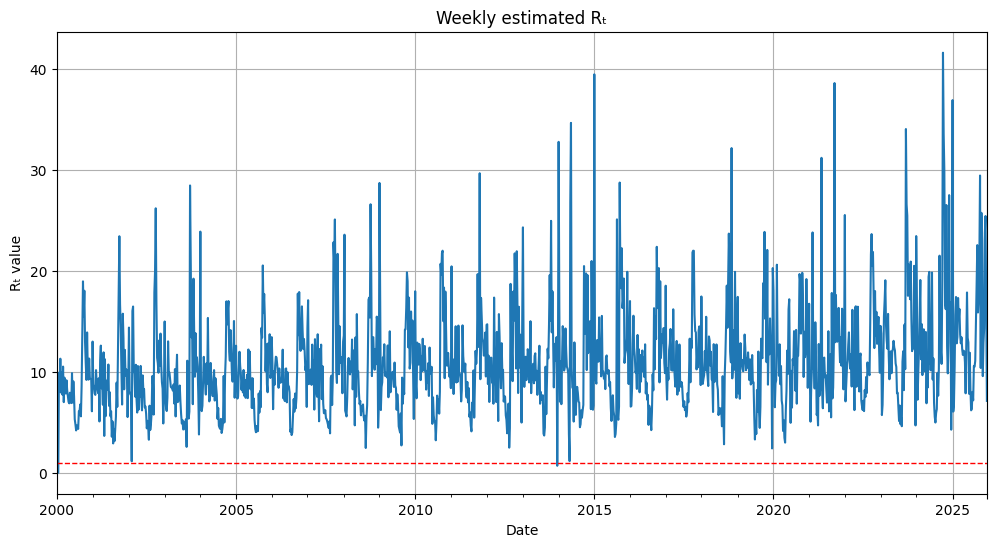

In [55]:
for t in range(max_tau, T):
    s_t = S_scen0[t] / N[t]
    R_t[t] = remainders_t[t] * s_t

weekly_remainders_t = pd.Series(remainders_t, index=weekly_cases_filled.index)
weekly_Rt = pd.Series(R_t, index=weekly_cases_filled.index)

plt.figure(figsize=(12, 6))
weekly_remainders_t.plot()

plt.axhline(1.0, color='red', linestyle='--', linewidth=1)  # R=1 as reference
plt.title("Weekly estimated Rₜ")
plt.ylabel("Rₜ value")
plt.xlabel("Date")
plt.grid(True)

plt.show()

## 6. Plot results for the number of incidences

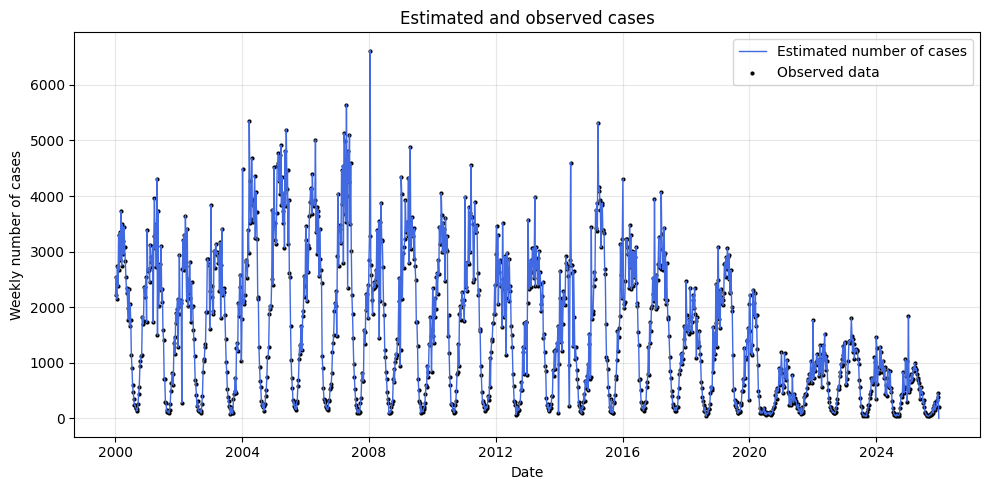

In [56]:
i_model = np.zeros(T)
for t in range(0, max_tau):
    i_model[t] = i[t]

for t in range(max_tau, T-1):
    s_t = S_scen0[t] / N[t]
    #i_model[t] = s_t * R_t[t] * np.sum(i_model[t - np.arange(1, max_tau+1)] * g)
    mu_t = weekly_deaths.iloc[t] / N[t]
    kernel = g * np.exp(-mu_t * np.arange(1, max_tau+1))
    i_model[t] = R_t[t] * np.sum(i_model[t - np.arange(1, max_tau+1)] * kernel)

weekly_i_model = pd.Series(i_model, index=weekly_cases_filled.index)

plt.figure(figsize=(10, 5))

plt.plot(weekly_i_model.index, weekly_i_model.values,
         label="Estimated number of cases", color="royalblue", linewidth=1)

plt.scatter(
    weekly_cases_filled.index,
    weekly_cases_filled.values,
    color="black",
    s=4,
    label="Observed data"
)

plt.title("Estimated and observed cases")
plt.xlabel("Date")
plt.ylabel("Weekly number of cases")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Incidences without vaccination

In [85]:
S_scen1 = np.zeros(T)
i_scen1 = np.zeros(T)
R_t_scen1 = np.zeros(T)
effectively_vaccinated = np.zeros(T)
demographic_changes = np.zeros(T)
vaccination_level = 0

for t in range(0, max_tau):
    i_scen1[t] = i_model[t]
    S_scen1[t] = S_scen0[t]

for t in range(max_tau, T-1):
    effectively_vaccinated[t] = (v1[t - 1] * V1_efficacy + v2[t - 1] * V1_efficacy * (1 - V1_efficacy)) * vaccination_level
    demographic_changes[t] = weekly_births.iloc[t - 1] - weekly_deaths.iloc[t - 1] * (S_scen1[t - 1] / N[t - 1])

    S_scen1[t] = S_scen1[t - 1] - i_scen1[t - 1] - effectively_vaccinated[t] + demographic_changes[t]
    s_t = S_scen1[t] / N[t]
    R_t_scen1[t] = remainders_t[t] * s_t

    mu_t = weekly_deaths.iloc[t] / N[t]
    kernel = g * np.exp(-mu_t * np.arange(1, max_tau+1))
    i_scen1[t] = R_t_scen1[t] * np.sum(i_scen1[t - np.arange(1, max_tau+1)] * kernel)

weekly_i_scen1 = pd.Series(i_scen1, index=weekly_cases_filled.index)

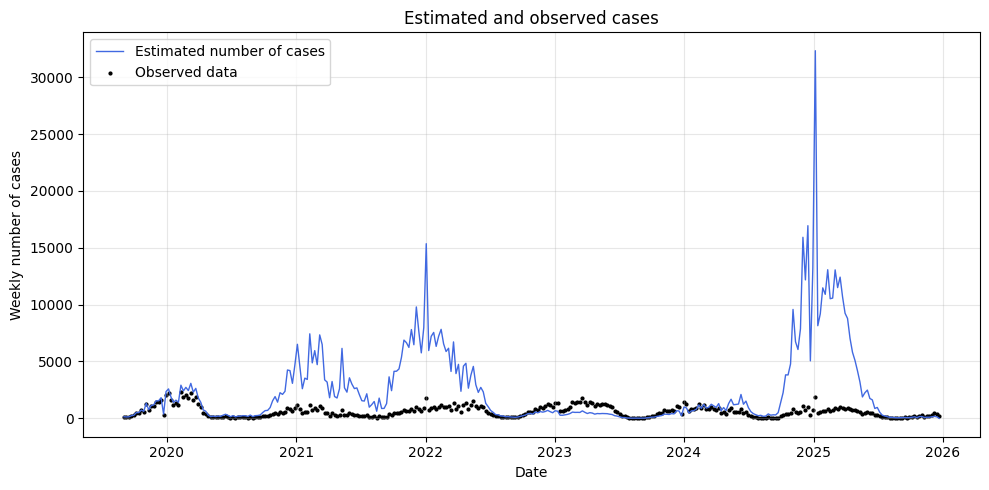

In [86]:
plt.figure(figsize=(10, 5))

plt.plot(weekly_i_scen1[weekly_i_scen1.index > start_of_vaccination].index, weekly_i_scen1[weekly_i_scen1.index > start_of_vaccination].values,
         label="Estimated number of cases", color="royalblue", linewidth=1)

plt.scatter(
    weekly_cases_filled[weekly_cases_filled.index > start_of_vaccination].index,
    weekly_cases_filled[weekly_cases_filled.index > start_of_vaccination].values,
    color="black",
    s=4,
    label="Observed data"
)

plt.title("Estimated and observed cases")
plt.xlabel("Date")
plt.ylabel("Weekly number of cases")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
annual_infections = weekly_i_scen1.groupby(weekly_i_scen1.index.year).sum()
print(annual_infections)

2000     94968.750000
2001     97482.500000
2002     88320.000000
2003     88680.000000
2004    120051.250000
2005    133032.500000
2006    114852.500000
2007    123942.500000
2008     92637.500000
2009    104282.500000
2010     98080.000000
2011    100637.500000
2012     85265.000000
2013     87800.000000
2014     72642.500000
2015    107595.000000
2016     95072.500000
2017     85597.500000
2018     62517.500000
2019     76925.425630
2020     67437.411988
2021    204198.598299
2022    140520.968265
2023     16029.618463
2024    142619.586669
2025    212172.900021
dtype: float64


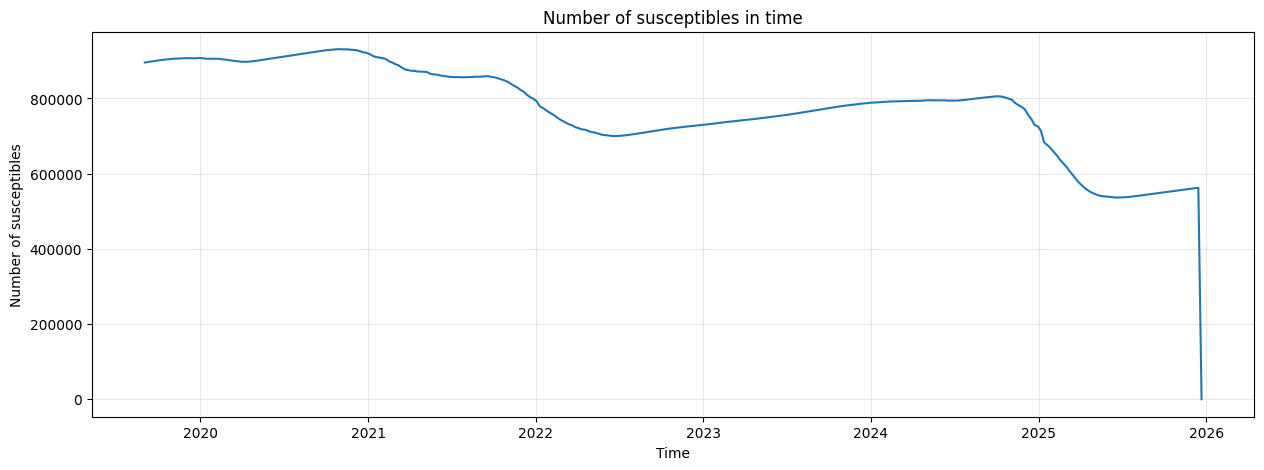

In [81]:
weekly_S_scen1 = pd.Series(S_scen1, index=weekly_cases_filled.index)

plt.figure(figsize=(15, 5))

plt.plot(weekly_S_scen1.index[weekly_S_scen1.index > start_of_vaccination],weekly_S_scen1.values[weekly_S_scen1.index > start_of_vaccination])
plt.xlabel("Time")
plt.ylabel("Number of susceptibles")
plt.title("Number of susceptibles in time")
plt.grid(alpha=0.3)
plt.show()

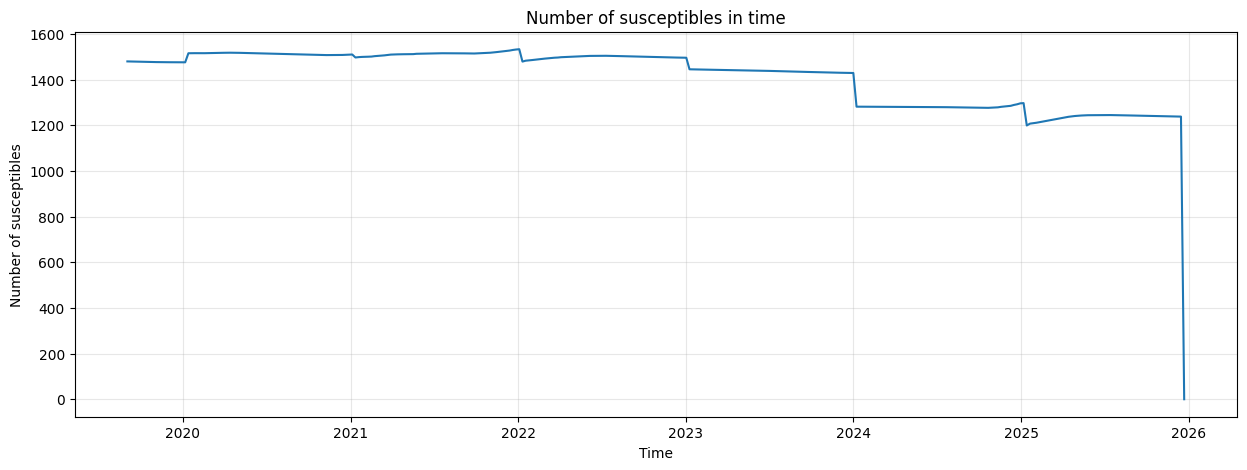

In [83]:
weekly_demographic_changes = pd.Series(demographic_changes, index=weekly_cases_filled.index)

plt.figure(figsize=(15, 5))

plt.plot(weekly_demographic_changes.index[weekly_demographic_changes.index > start_of_vaccination],weekly_demographic_changes.values[weekly_demographic_changes.index > start_of_vaccination])
plt.xlabel("Time")
plt.ylabel("Number of susceptibles")
plt.title("Number of susceptibles in time")
plt.grid(alpha=0.3)
plt.show()

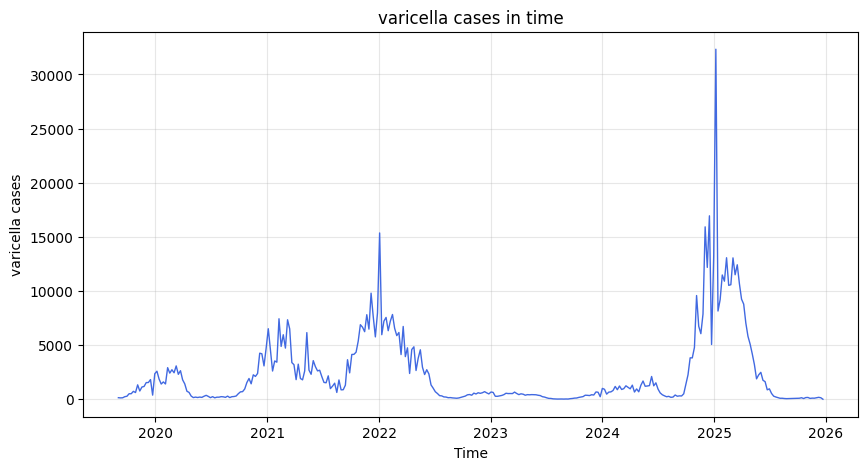

In [84]:
plt.figure(figsize=(10, 5))

plt.plot(weekly_i_scen1[weekly_i_scen1.index > start_of_vaccination].index, weekly_i_scen1[weekly_i_scen1.index > start_of_vaccination].values,
         label="Estimated number of cases", color="royalblue", linewidth=1)
plt.xlabel("Time")
plt.ylabel("varicella cases")
plt.title("varicella cases in time")
plt.grid(alpha=0.3)
plt.show()

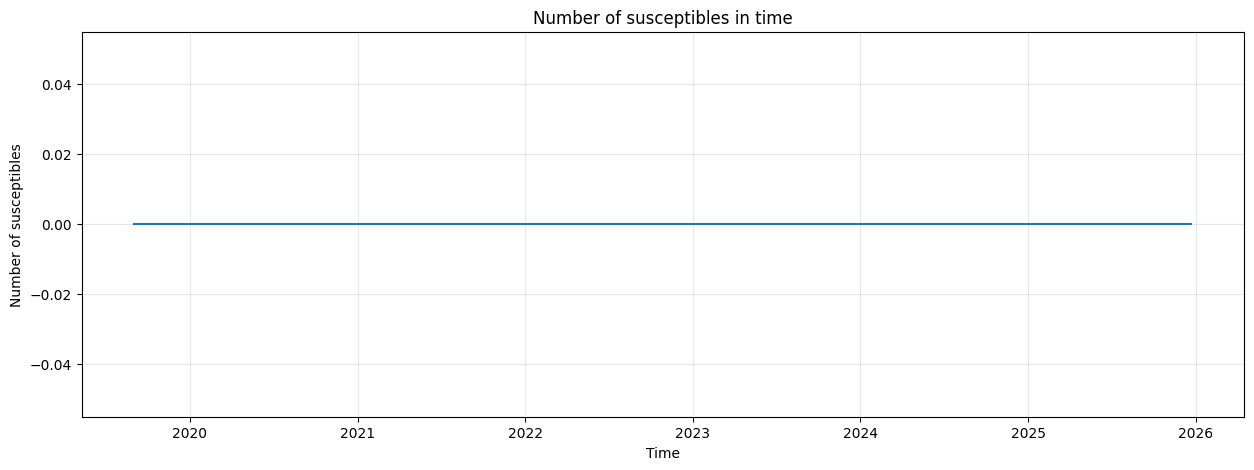

In [87]:
weekly_effectively_vaccinated = pd.Series(effectively_vaccinated, index=weekly_cases_filled.index)

plt.figure(figsize=(15, 5))

plt.plot(weekly_effectively_vaccinated.index[weekly_effectively_vaccinated.index > start_of_vaccination],weekly_effectively_vaccinated.values[weekly_effectively_vaccinated.index > start_of_vaccination])
plt.xlabel("Time")
plt.ylabel("Number of susceptibles")
plt.title("Number of susceptibles in time")
plt.grid(alpha=0.3)
plt.show()